In [10]:
class MeraLR:
  def __init__(self):
    self.m=None
    self.b=None
  def fit(self ,x_train,y_train):
    num=0
    denum=0
    for i in range(x_train.shape[0]):
     num=num+((x_train[i]-x_train.mean())*(y_train[i]-y_train.mean()))
     denum=denum+((x_train[i]-x_train.mean())*(x_train[i]-x_train.mean()))
    self.m=num/denum
    self.b=y_train.mean()-(self.m*x_train.mean())
    print(self.m)
    print(self.b)



  def predict(self,x_test):
   return self.m*x_test+self.b



In [11]:
class MeraMR1:
  def __init__(self):
    self.coe=None
    self.intercept=None
  def fit1(self,x_train,y_train):
    x_train=np.insert(x_train,0,1,axis=1)

    be=np.dot(np.linalg.inv(np.dot(x_train.T,x_train)),np.dot(x_train.T,y_train))
    self.coe=be[1:]
    self.intercept=be[0]
    print(be)

  def predict1(self,x_test):
    return np.dot(x_test,self.beta)




In [4]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

import numpy as np

In [5]:
X_diabetes,Y=datasets.load_diabetes(return_X_y=True)

In [6]:
X=X_diabetes[:,np.newaxis,2]

In [7]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [28]:
x_train.shape

(353, 1)

In [12]:
lr=MeraLR()

In [13]:
lr.fit(x_train,y_train)

[974.48209999]
[152.45404936]


In [14]:
x_train.shape[0]

353

In [15]:
x_train[0]

array([-0.06979687])

In [16]:
y_pred=lr.predict(x_test)

In [17]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error

In [18]:
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)

In [19]:
print(mse)
print(rmse)
print(r2)
print(mae)

3898.2586095405527
62.43603614532678
0.29445364408316665
49.325126131634555


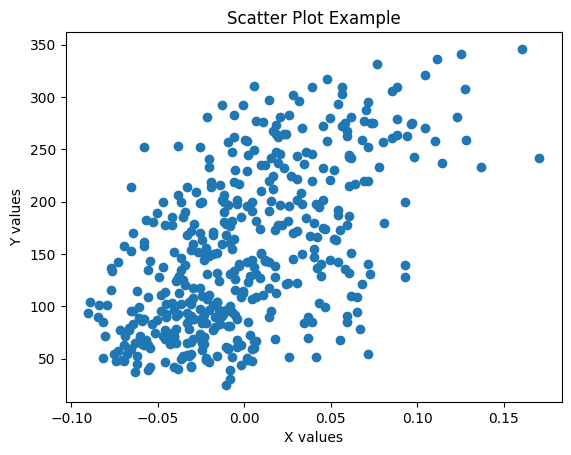

In [21]:
import matplotlib.pyplot as plt
import numpy as np


plt.scatter(X, Y)
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter Plot Example")
plt.show()

In [46]:
x1_train,x1_test,y1_train,y1_test=train_test_split(X_diabetes,Y,test_size=0.2,random_state=42)

In [47]:
lr1=MeraMR1()

In [48]:
lr1.fit1(x1_train,y1_train)

[ 151.34560454   37.90402135 -241.96436231  542.42875852  347.70384391
 -931.48884588  518.06227698  163.41998299  275.31790158  736.1988589
   48.67065743]


In [52]:
y1_pre=lr.predict(x_test)

In [54]:
mse=mean_squared_error(y1_test,y1_pre)
rmse=np.sqrt(mse)
r2=r2_score(y1_test,y1_pre)
mae=mean_absolute_error(y1_test,y1_pre)

In [55]:
print(mse)
print(rmse)
print(r2)
print(mae)

9158.484585494729
95.69997171104455
-0.7286187750396087
81.39643121220269


In [56]:
from sklearn.linear_model import LinearRegression


In [57]:
model1=LinearRegression()

In [58]:
model1.fit(x_train,y_train)

LinearRegression()

In [59]:
model1.coef_

array([974.48209999])

In [60]:
model1.intercept_

np.float64(152.45404935855575)

In [61]:
model2=LinearRegression()

In [62]:
model2.fit(x1_train,y1_train)

LinearRegression()

In [63]:
model2.coef_

array([  37.90402135, -241.96436231,  542.42875852,  347.70384391,
       -931.48884588,  518.06227698,  163.41998299,  275.31790158,
        736.1988589 ,   48.67065743])

In [76]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler



In [77]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [78]:
model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    random_state=42
)

model.fit(x_train_scaled, y_train)


BaggingRegressor(estimator=DecisionTreeRegressor(), max_samples=0.8,
                 n_estimators=100, random_state=42)

In [79]:
y_pred = model.predict(x_test_scaled)


In [80]:
r2=r2_score(y_test,y_pred)

In [81]:
print(r2)

0.09468778012277568


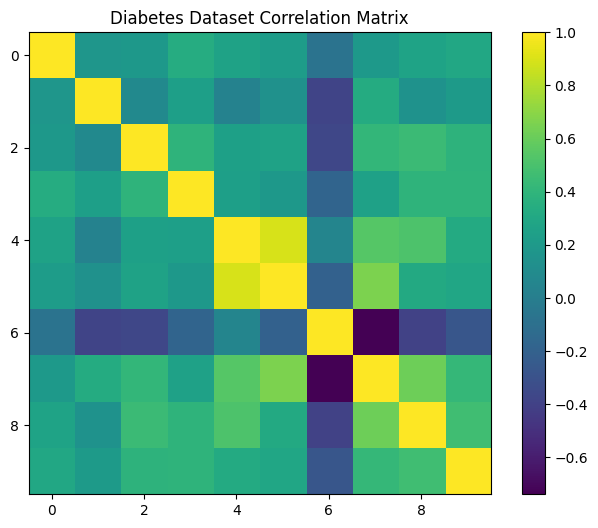

In [22]:
corr = np.corrcoef(X_diabetes, rowvar=False)

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.title("Diabetes Dataset Correlation Matrix")
plt.show()


In [23]:
print(X_diabetes)

[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]
